# Step 1 — Import Libraries
Import all required libraries for feature extraction.

In [1]:
# Step 1 — Import Libraries

import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage.feature import local_binary_pattern

from sklearn.preprocessing import StandardScaler

from tqdm import tqdm

print("Libraries imported successfully")

Libraries imported successfully


# Step 2 — Load Processed Dataset

Load the preprocessed training dataset that will be used for feature extraction.

In [2]:
import numpy as np

data = np.load('processed_train_enhanced.npy.npz')

X = data['X']
y = data['y']

print("Dataset Loaded Successfully")

print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset Loaded Successfully
X shape: (4844, 128, 128, 1)
y shape: (4844,)


# Step 3 — Quick Data Check

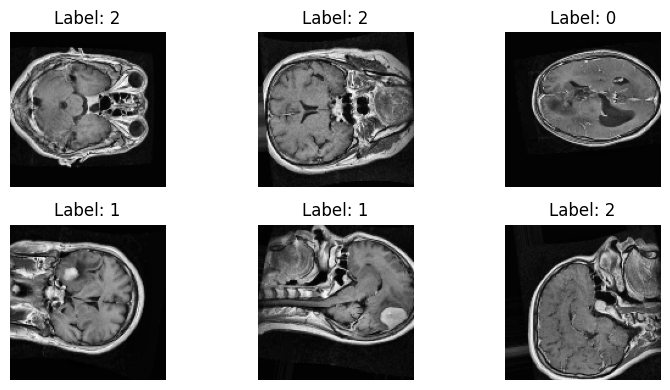

Images checked ✅


In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(X[i,:,:,0], cmap='gray')

    plt.title(f"Label: {y[i]}")

    plt.axis('off')

plt.tight_layout()
plt.show()

print("Images checked ✅")

#Step 4 — HOG Feature Extraction

In [4]:


hog_features = []

for img in tqdm(X):

    img2d = img[:, :, 0]  # remove channel

    features = hog(
        img2d,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm='L2-Hys'
    )

    hog_features.append(features)

hog_features = np.array(hog_features)

print("HOG Extraction Done ✅")
print("HOG Shape:", hog_features.shape)

100%|██████████| 4844/4844 [00:38<00:00, 124.46it/s]

HOG Extraction Done ✅
HOG Shape: (4844, 8100)


# Step 5 — Save HOG Features

In [5]:


np.save("hog_features.npy", hog_features)

print("HOG Features Saved Successfully ✅")

HOG Features Saved Successfully ✅


# Step 6 — LBP Feature Extraction

In [6]:


lbp_features = []

radius = 1
n_points = 8 * radius

for img in tqdm(X):

    img2d = img[:, :, 0]

    lbp = local_binary_pattern(
        img2d,
        n_points,
        radius,
        method="uniform"
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2)
    )

    hist = hist.astype("float")

    hist /= hist.sum()  # normalize histogram

    lbp_features.append(hist)

lbp_features = np.array(lbp_features)

print("LBP Extraction Done ✅")
print("LBP Shape:", lbp_features.shape)

  0%|          | 0/4844 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
100%|██████████| 4844/4844 [00:22<00:00, 218.52it/s]

LBP Extraction Done ✅
LBP Shape: (4844, 10)


# Step 7 — Save LBP Features

In [7]:


np.save("lbp_features.npy", lbp_features)

print("LBP Features Saved Successfully ✅")

LBP Features Saved Successfully ✅


# Step 8 — Combine HOG + LBP

In [8]:


final_features = np.concatenate(
    [hog_features, lbp_features],
    axis=1
)

print("Features Combined Successfully ✅")
print("Final Features Shape:", final_features.shape)

Features Combined Successfully ✅
Final Features Shape: (4844, 8110)


# Step 9 — Normalize Features

In [9]:


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(final_features)

print("Normalization Done ✅")
print("Scaled Features Shape:", X_scaled.shape)

Normalization Done ✅
Scaled Features Shape: (4844, 8110)


# Step 10 — Save Final Features

In [10]:


np.save("X_features.npy", X_scaled)
np.save("y_labels.npy", y)

print("Final Features Saved Successfully ✅")

Final Features Saved Successfully ✅
